In [17]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,precision_score,recall_score,roc_auc_score
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
if 'RowNumber' in df.columns:
    df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [4]:
#Encode categorical data
le=LabelEncoder()
df['Geography']=le.fit_transform(df['Geography'])
df['Gender']=le.fit_transform(df['Gender'])
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [5]:
#Features in X and target in Y
X=df.iloc[:,:-1]
Y=df.iloc[:,-1]

In [6]:
#Split dataset into training set and testing set
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)
print(X_train.shape,X_test.shape)

(8000, 10) (2000, 10)


In [7]:
#Feature scaling and standardization
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [8]:
#Initalize ANN and add layers
ann=tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=6,activation='relu'))
ann.add(tf.keras.layers.Dense(units=6,activation='relu'))
ann.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))

In [9]:
#compile and set callbacks for the Model
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)
reduce_lr=tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=10,
    min_lr=0.0001)

In [10]:
#train the model
history=ann.fit(
    X_train,Y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test,Y_test))

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.5219 - val_accuracy: 0.7985 - val_loss: 0.4791
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7993 - loss: 0.4684 - val_accuracy: 0.8050 - val_loss: 0.4482
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8031 - loss: 0.4490 - val_accuracy: 0.8070 - val_loss: 0.4352
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8021 - loss: 0.4397 - val_accuracy: 0.8095 - val_loss: 0.4291
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8048 - loss: 0.4337 - val_accuracy: 0.8130 - val_loss: 0.4248
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8065 - loss: 0.4285 - val_accuracy: 0.8160 - val_loss: 0.4211
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8060 - loss: 0.4235 - val_accuracy: 0.8175 - val_loss: 0.4171
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8099 - loss: 0.4188 - val_accu

In [11]:
print(ann.predict(sc.transform([[1,600,1,40,3,60000,2,1,1,50000]]))>0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[False]]


C:\Users\abhim\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
Y_pred=ann.predict(X_test)
Y_pred=(Y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step


In [13]:
cm=confusion_matrix(Y_test,Y_pred)
acc=accuracy_score(Y_test,Y_pred)
cr=classification_report(Y_test,Y_pred)
print(f'Confusion Matrix\n{cm}\nAccuracy:{acc}\nClassification Report\n{cr}')

Confusion Matrix
[[1526   69]
 [ 198  207]]
Accuracy:0.8665
Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1595
           1       0.75      0.51      0.61       405

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [14]:
print('Evaluating the model')
train_loss,train_acc=ann.evaluate(X_train,Y_train,verbose=0)
test_loss,test_acc=ann.evaluate(X_test,Y_test,verbose=0)
print(f'''Loss in train set:{train_loss}
Accuaracy in train set:{train_acc}
Loss in test set:{test_loss}
Accuaracy in test set:{test_acc}''')

Evaluating the model
Loss in train set:0.33326011896133423
Accuaracy in train set:0.8648750185966492
Loss in test set:0.3358362913131714
Accuaracy in test set:0.8665000200271606


In [15]:
#For training set
y_train=ann.predict(X_train)
y_train=(y_train>0.5)
train_precision=precision_score(y_train,Y_train)
train_recall=recall_score(y_train,Y_train)
train_auc=roc_auc_score(y_train,Y_train)
#For testing set
y_test=ann.predict(X_test)
y_test=(y_test>0.5)
test_precision=precision_score(y_test,Y_test)
test_recall=recall_score(y_test,Y_test)
test_auc=roc_auc_score(y_test,Y_test)

250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step


In [16]:
print(f'''Training Set:
Accuracy:{train_acc}
Loss:{train_loss}
Precision Score:{train_precision}
Recall Score:{train_recall}
Auc Score:{train_auc}
Testing Set:
Accuracy:{test_acc}
Loss:{test_loss}
Precision Score:{test_precision}
Recall Score:{test_recall}
Auc Score:{test_auc}
''')

Training Set:
Accuracy:0.8648750185966492
Loss:0.33326011896133423
Precision Score:0.47732843137254904
Recall Score:0.7735849056603774
Auc Score:0.8258028918406277
Testing Set:
Accuracy:0.8665000200271606
Loss:0.3358362913131714
Precision Score:0.5111111111111111
Recall Score:0.75
Auc Score:0.8175754060324826



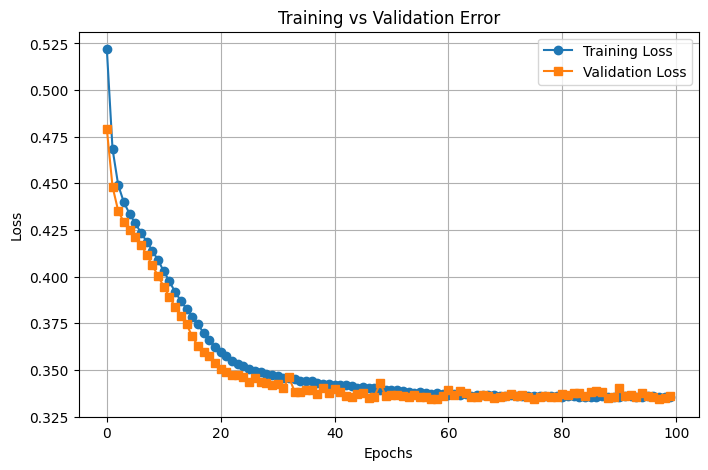

In [21]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label='Training Loss',marker='o')
plt.plot(history.history['val_loss'],label='Validation Loss',marker='s')
plt.title('Training vs Validation Error')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

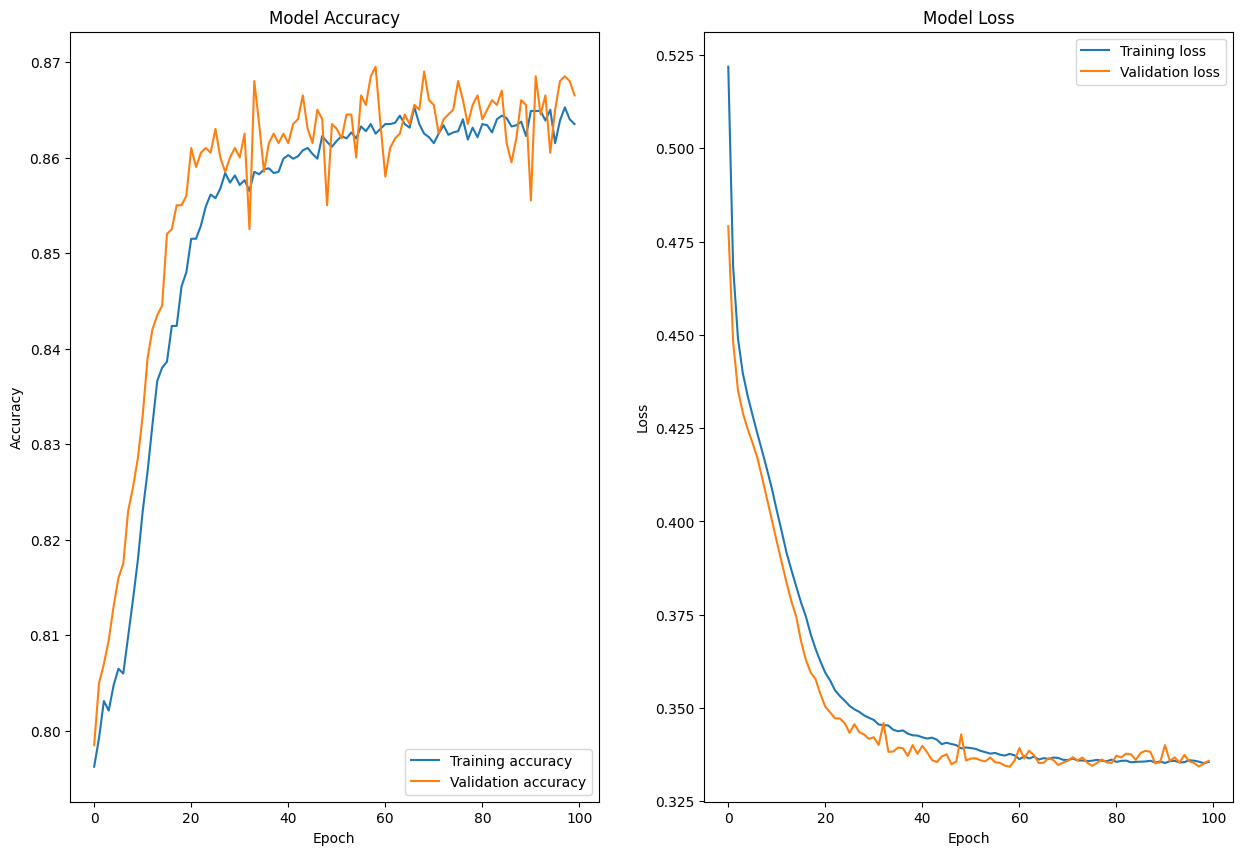

In [22]:
def plot_training_history(history):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,10))

    #Plot for accuracy
    ax1.plot(history.history['accuracy'],label='Training accuracy')
    ax1.plot(history.history['val_accuracy'],label='Validation accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    #Plot for loss
    ax2.plot(history.history['loss'],label='Training loss')
    ax2.plot(history.history['val_loss'],label='Validation loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

plot_training_history(history)